# Non-Parametric Survival Analysis of Pancreatic Cancer
## Part 1: Comprehensive Estimation Using the Kaplan-Meier Framework

### 1.1. Introduction and Data Source
This study focuses on analyzing the survival trajectories of pancreatic cancer patients using data from the [Kaggle Pancreatic Cancer Dataset](https://www.kaggle.com/datasets/zkskhurram/pancreatic-cancer-global-clinical-and-risk-factor). Pancreatic cancer is one of the most aggressive malignancies, and traditional regression models often fail to handle its specific time-to-event structure due to **censoring** (patients alive at the end of the study or lost to follow-up). 

Our entire analysis in this phase is strictly non-parametric, relying on the **Kaplan-Meier Estimator** to calculate and visualize survival probabilities over time across the entire cohort and specific clinical strata.

### 1.2. Mathematical Formulation of the Kaplan-Meier Estimator
The survival function $S(t)$ represents the probability that an individual survives longer than time $t$. The Kaplan-Meier (product-limit) estimator non-parametrically estimates this probability from discrete clinical observations:

$$S(t) = \prod_{t_i \le t} \left(1 - \frac{d_i}{n_i}\right)$$

Where:
* $t_i$ represents a distinct time point (measured in `Survival_Months`) where at least one patient death occurred.
* $d_i$ is the number of events (deaths) recorded at that specific time point $t_i$.
* $n_i$ is the total number of patients "at risk" (alive and under observation) immediately prior to $t_i$.

Censored observations directly affect $n_i$ by reducing the number of people at risk in subsequent steps, but they do not count as events ($d_i=0$), preventing statistical bias.

In [1]:
import pandas as pd 
import numpy as np  
import matplotlib.pyplot as plt 

from lifelines import KaplanMeierFitter

In [2]:
cancer_data = pd.read_csv("pancreatic_cancer_dataset_cleaned.csv")

In [3]:
cancer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 51 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Patient_ID            2000 non-null   object 
 1   Diagnosis_Year        2000 non-null   int64  
 2   Diagnosis_Date        2000 non-null   object 
 3   WHO_Region            2000 non-null   object 
 4   Country               2000 non-null   object 
 5   Age                   2000 non-null   int64  
 6   Gender                2000 non-null   object 
 7   Ethnicity             2000 non-null   object 
 8   Smoking_Status        2000 non-null   object 
 9   Pack_Years            2000 non-null   int64  
 10  Alcohol_Use           2000 non-null   object 
 11  BMI                   2000 non-null   float64
 12  BMI_Category          2000 non-null   object 
 13  Diabetes_Status       2000 non-null   object 
 14  Chronic_Pancreatitis  2000 non-null   object 
 15  Family_History       

In [4]:
bins = [0, 20, 30, 40, 50, 60, 70, float("inf")]  
labels = ["0-19", "20-29","30-39", "40-49", "50-59", "60-69", "70+"]

cancer_data["Age_Group"] = pd.cut(cancer_data["Age"], bins=bins, labels=labels, right=False)

print(cancer_data["Age_Group"].value_counts().sort_index())

Age_Group
0-19       0
20-29      0
30-39      8
40-49     64
50-59    384
60-69    813
70+      731
Name: count, dtype: int64


## 2. Global Fleet Baseline: Population-Wide Survival Curve
We first fit the Kaplan-Meier estimator on the entire cohort to calculate the baseline survival curve, the overall median survival time, and its associated 95% confidence intervals.

##  <center>**Overall Kaplan-Meier (all patients)**</center>

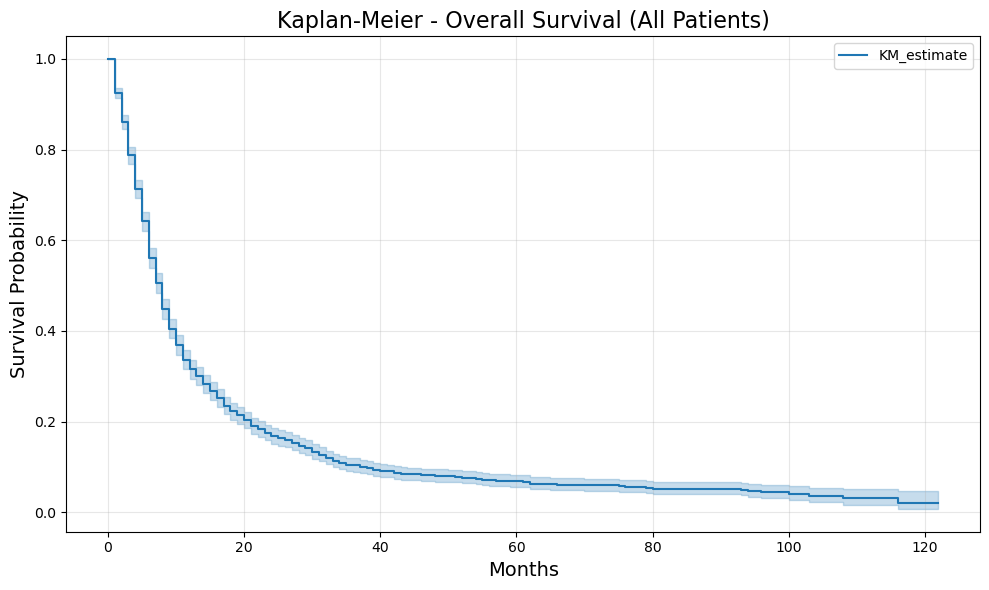

Median survival time: 8.0 months
95% confidence interval:        KM_estimate_lower_0.95  KM_estimate_upper_0.95
0.0                  1.000000                1.000000
1.0                  0.912566                0.935729
2.0                  0.845391                0.875745
3.0                  0.768701                0.804650
4.0                  0.693180                0.732923
...                       ...                     ...
108.0                0.016741                0.050409
112.0                0.016741                0.050409
116.0                0.006720                0.047741
117.0                0.006720                0.047741
122.0                0.006720                0.047741

[97 rows x 2 columns]


In [5]:
kmf = KaplanMeierFitter()
kmf.fit(cancer_data["Survival_Months"], event_observed=cancer_data["Survived"])

# Plot
plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.title("Kaplan-Meier - Overall Survival (All Patients)", fontsize=16)
plt.xlabel("Months", fontsize=14)
plt.ylabel("Survival Probability", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Median survival time: {kmf.median_survival_time_:.1f} months")
print(f"95% confidence interval: {kmf.confidence_interval_}")

##  <center><span style="color:blue;">**Kaplan-Meier by Smoking Status**</span></center>

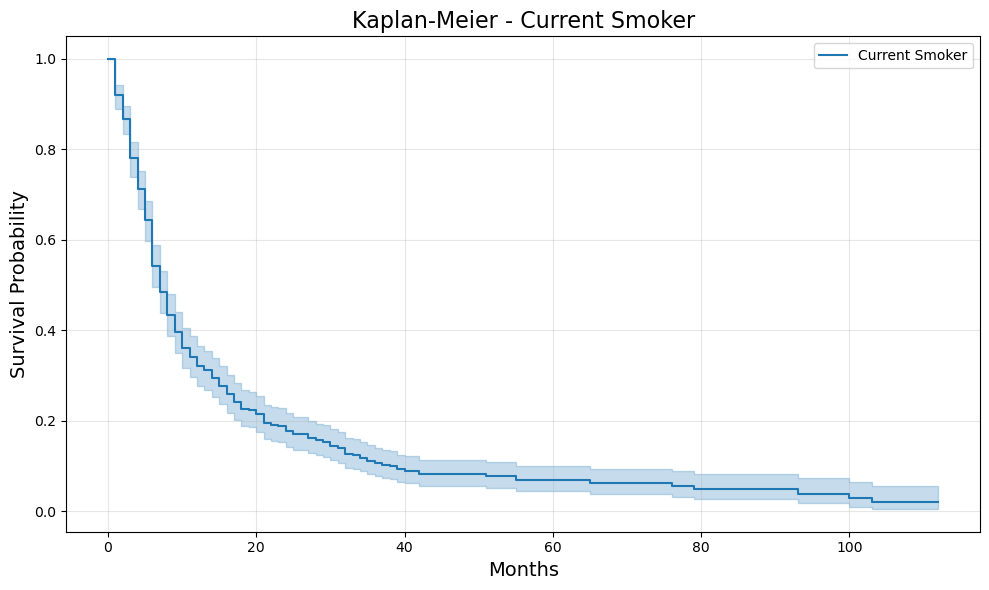

Group: Current Smoker
  Patients: 447
  Deaths: 397
  Median survival: 7.0 months
  95% CI:        Current Smoker_lower_0.95  Current Smoker_upper_0.95
0.0                     1.000000                   1.000000
1.0                     0.890106                   0.941237
2.0                     0.832829                   0.896048
3.0                     0.738541                   0.815663
4.0                     0.667835                   0.752019
...                          ...                        ...
93.0                    0.017636                   0.074096
100.0                   0.010393                   0.065376
103.0                   0.004733                   0.055457
105.0                   0.004733                   0.055457
112.0                   0.004733                   0.055457

[62 rows x 2 columns]


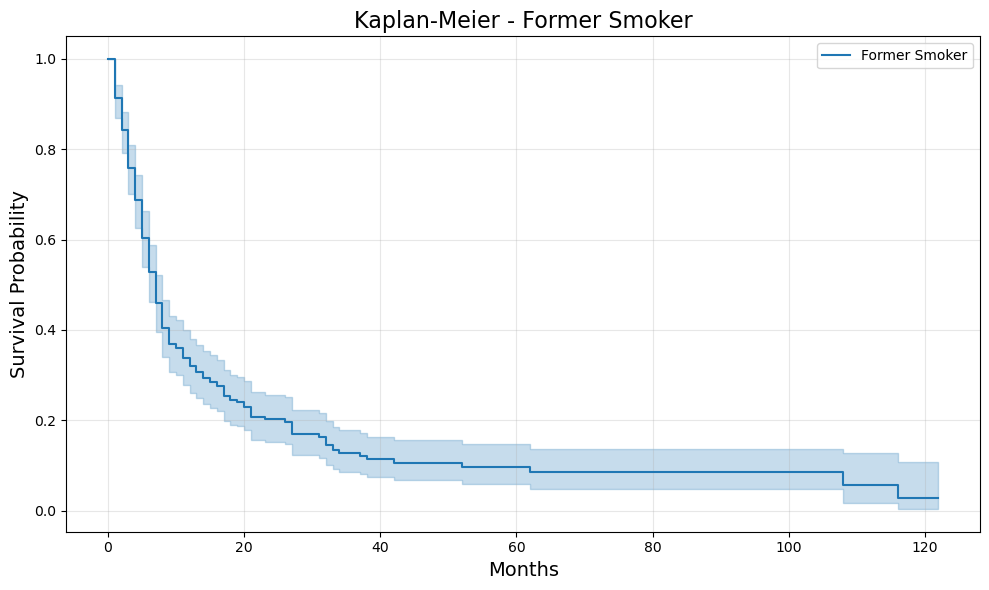

Group: Former Smoker
  Patients: 242
  Deaths: 207
  Median survival: 7.0 months
  95% CI:        Former Smoker_lower_0.95  Former Smoker_upper_0.95
0.0                    1.000000                  1.000000
1.0                    0.870015                  0.942540
2.0                    0.790692                  0.883163
3.0                    0.700378                  0.808584
4.0                    0.625895                  0.742937
5.0                    0.539141                  0.662821
6.0                    0.462772                  0.589061
7.0                    0.394956                  0.521293
8.0                    0.340795                  0.465338
9.0                    0.307897                  0.430492
10.0                   0.299506                  0.421548
11.0                   0.278341                  0.398845
12.0                   0.261530                  0.380572
13.0                   0.248993                  0.366800
14.0                   0.236521        

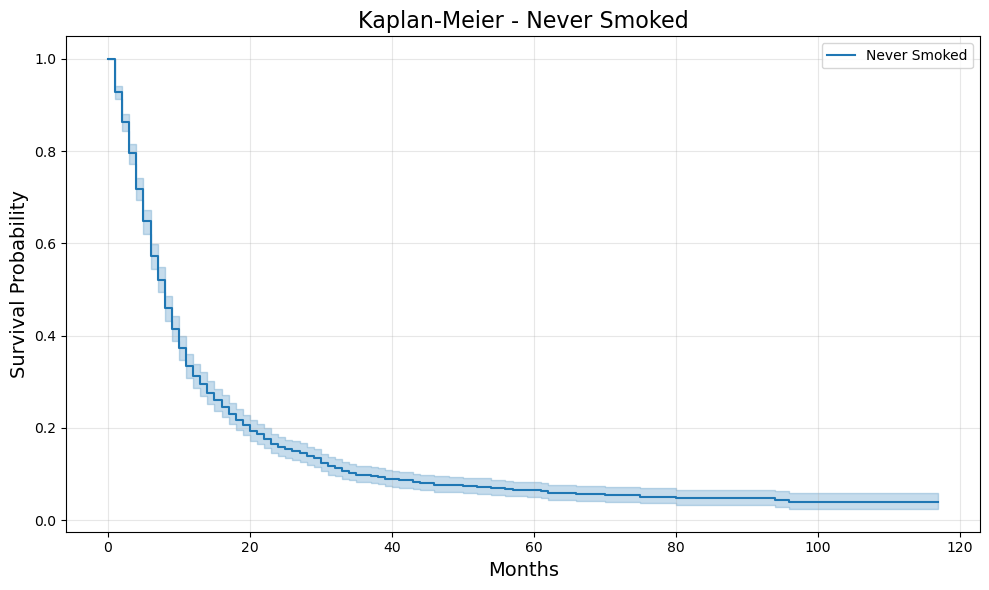

Group: Never Smoked
  Patients: 1_311
  Deaths: 1_158
  Median survival: 8.0 months
  95% CI:        Never Smoked_lower_0.95  Never Smoked_upper_0.95
0.0                   1.000000                 1.000000
1.0                   0.913779                 0.941722
2.0                   0.842622                 0.880016
3.0                   0.772035                 0.815855
4.0                   0.693364                 0.742200
...                        ...                      ...
102.0                 0.023526                 0.058723
106.0                 0.023526                 0.058723
107.0                 0.023526                 0.058723
112.0                 0.023526                 0.058723
117.0                 0.023526                 0.058723

[79 rows x 2 columns]


In [6]:
smoking_groups = cancer_data["Smoking_Status"].unique()

for group in smoking_groups:
    mask = cancer_data["Smoking_Status"] == group
    kmf = KaplanMeierFitter()
    kmf.fit(cancer_data[mask]["Survival_Months"], 
            event_observed=cancer_data[mask]["Survived"], 
            label=group)
    
    
    plt.figure(figsize=(10, 6))
    kmf.plot_survival_function()
    plt.title(f"Kaplan-Meier - {group}", fontsize=16)
    plt.xlabel("Months", fontsize=14)
    plt.ylabel("Survival Probability", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    

    print(f"Group: {group}")
    print(f"  Patients: {mask.sum():_}")
    print(f"  Deaths: {cancer_data[mask]['Survived'].sum():_}")
    print(f"  Median survival: {kmf.median_survival_time_:_.1f} months")
    print(f"  95% CI: {kmf.confidence_interval_}")
  

## <center><span style= "color: orange;">**By Alcohol Use**</span></center>

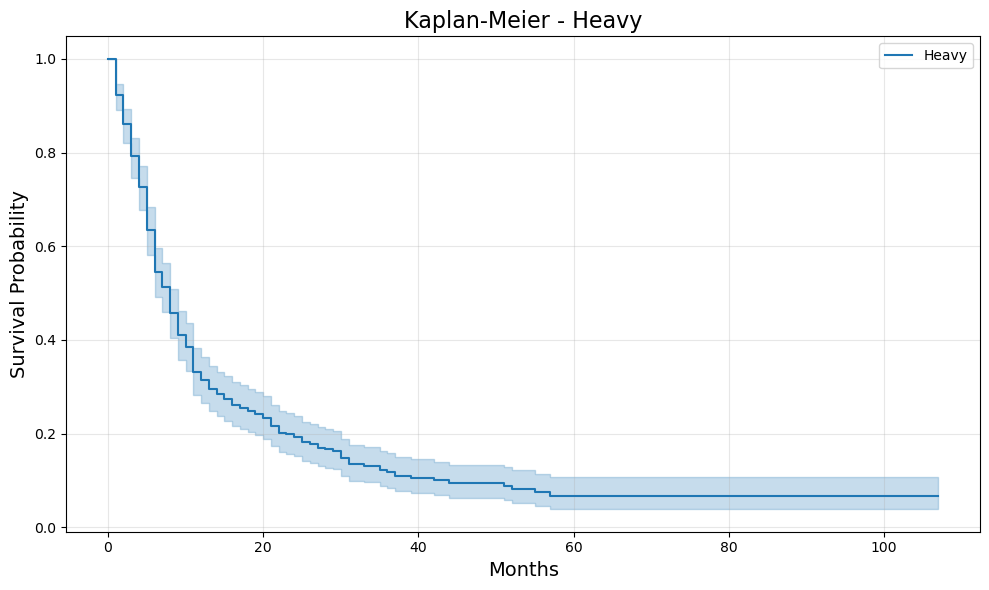

Group: Heavy
  Patients: 353
  Deaths: 303
  Median survival: 8.0 months
  95% CI:        Heavy_lower_0.95  Heavy_upper_0.95
0.0            1.000000          1.000000
1.0            0.890439          0.946899
2.0            0.820306          0.893077
3.0            0.746614          0.831528
4.0            0.677168          0.770421
5.0            0.582248          0.683008
6.0            0.490887          0.595330
7.0            0.458909          0.563794
8.0            0.403856          0.508526
9.0            0.357704          0.461196
10.0           0.334452          0.437033
11.0           0.282658          0.382169
12.0           0.265564          0.363719
13.0           0.248378          0.345025
14.0           0.236844          0.332396
15.0           0.227902          0.322617
16.0           0.216028          0.309533
17.0           0.210113          0.302971
18.0           0.204129          0.296323
19.0           0.198074          0.289586
20.0           0.188884          0.

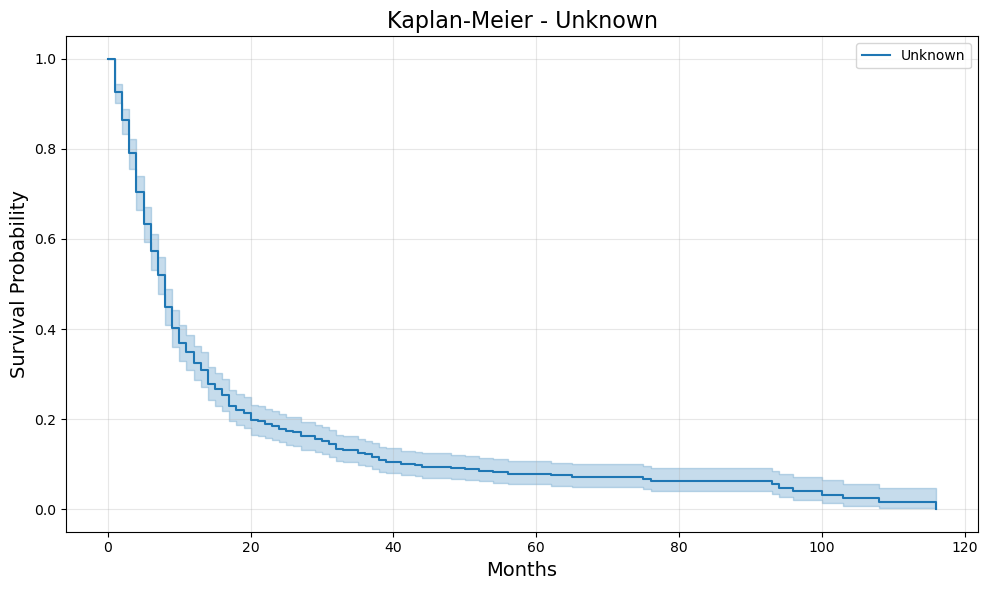

Group: Unknown
  Patients: 586
  Deaths: 517
  Median survival: 8.0 months
  95% CI:        Unknown_lower_0.95  Unknown_upper_0.95
0.0              1.000000            1.000000
1.0              0.902337            0.945051
2.0              0.832951            0.888807
3.0              0.755976            0.822015
4.0              0.664638            0.738796
...                   ...                 ...
100.0            0.013244            0.064583
103.0            0.007948            0.056294
108.0            0.003688            0.047260
112.0            0.003688            0.047260
116.0            0.000000            0.000000

[69 rows x 2 columns]


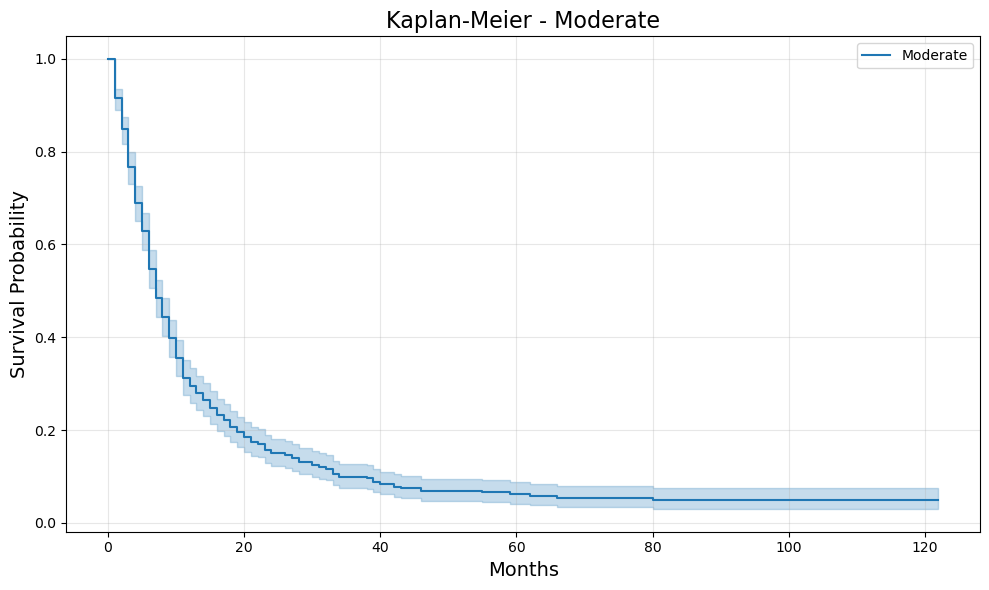

Group: Moderate
  Patients: 587
  Deaths: 526
  Median survival: 7.0 months
  95% CI:        Moderate_lower_0.95  Moderate_upper_0.95
0.0               1.000000             1.000000
1.0               0.889164             0.934757
2.0               0.816587             0.874882
3.0               0.729739             0.798380
4.0               0.650000             0.724987
...                    ...                  ...
102.0             0.029447             0.074826
105.0             0.029447             0.074826
112.0             0.029447             0.074826
117.0             0.029447             0.074826
122.0             0.029447             0.074826

[61 rows x 2 columns]


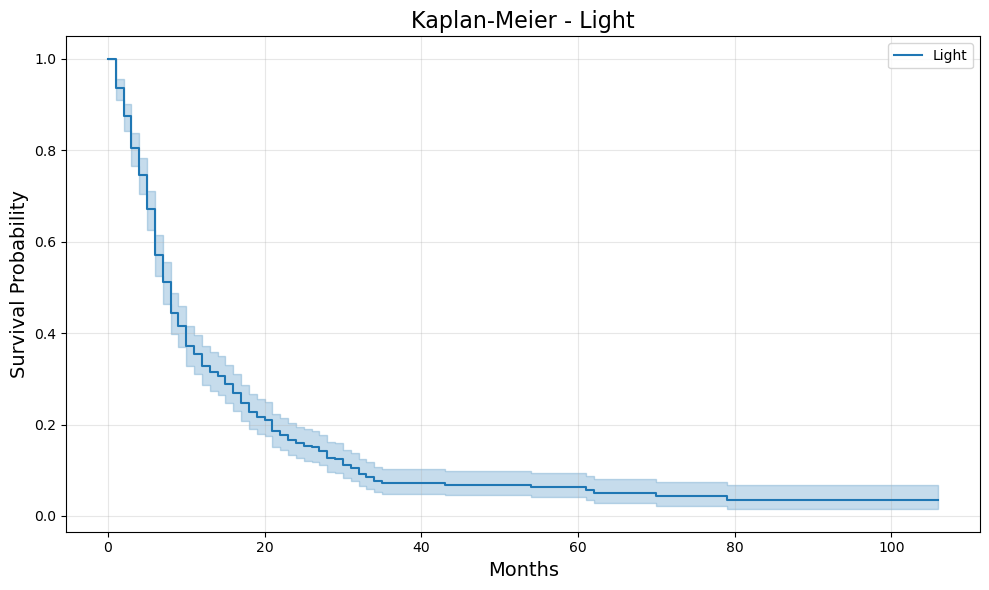

Group: Light
  Patients: 474
  Deaths: 416
  Median survival: 8.0 months
  95% CI:        Light_lower_0.95  Light_upper_0.95
0.0            1.000000          1.000000
1.0            0.910721          0.955317
2.0            0.841794          0.901823
3.0            0.765896          0.837720
4.0            0.704667          0.783485
5.0            0.626440          0.711622
6.0            0.525545          0.615293
7.0            0.464317          0.555111
8.0            0.397352          0.487682
9.0            0.369529          0.459154
10.0           0.327035          0.414965
11.0           0.309815          0.396892
12.0           0.286252          0.371933
13.0           0.273363          0.358178
14.0           0.264727          0.348926
15.0           0.247235          0.330113
16.0           0.229682          0.311076
17.0           0.207676          0.286961
18.0           0.190013          0.267385
19.0           0.178780          0.254861
20.0           0.174129          0.

In [7]:
alcohol_groups = cancer_data["Alcohol_Use"].unique()

for group in alcohol_groups:
    mask = cancer_data["Alcohol_Use"] == group
    kmf = KaplanMeierFitter()
    kmf.fit(cancer_data[mask]["Survival_Months"], 
            event_observed=cancer_data[mask]["Survived"], 
            label=group)
    
    
    plt.figure(figsize=(10, 6))
    kmf.plot_survival_function()
    plt.title(f"Kaplan-Meier - {group}", fontsize=16)
    plt.xlabel("Months", fontsize=14)
    plt.ylabel("Survival Probability", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    
    print(f"Group: {group}")
    print(f"  Patients: {mask.sum():_}")
    print(f"  Deaths: {cancer_data[mask]['Survived'].sum():_}")
    print(f"  Median survival: {kmf.median_survival_time_:_.1f} months")
    print(f"  95% CI: {kmf.confidence_interval_}")
    

## <center><span style= "color:green;">**By Age Group**</span></center>

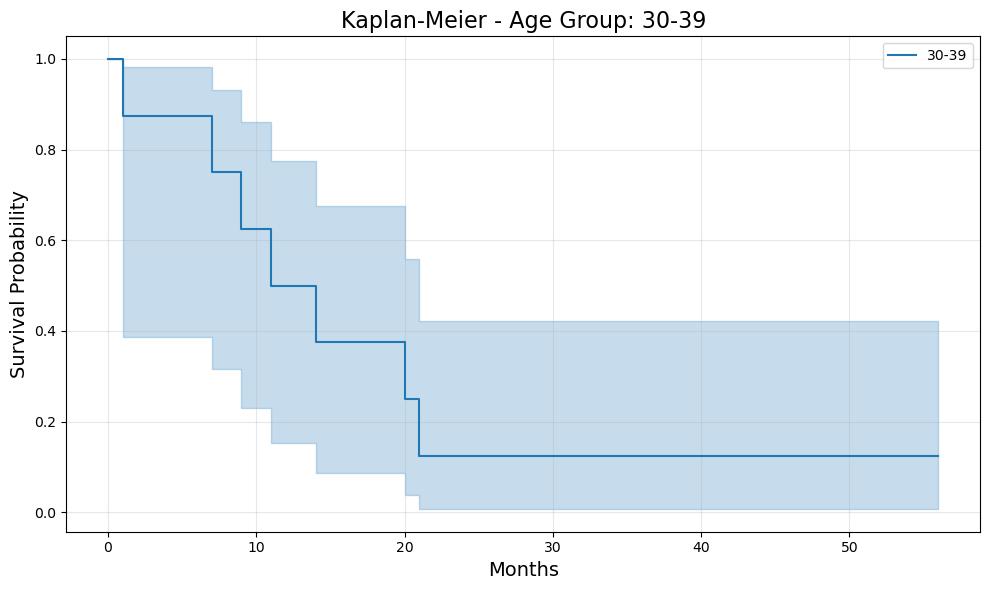

Group: 30-39
  Patients: 8
  Deaths: 7
  Median survival: 14.0 months
  95% CI:       30-39_lower_0.95  30-39_upper_0.95
0.0           1.000000          1.000000
1.0           0.387000          0.981393
7.0           0.314807          0.930898
9.0           0.229333          0.860698
11.0          0.152036          0.774865
14.0          0.087006          0.674363
20.0          0.037067          0.558084
21.0          0.006593          0.422706
56.0          0.006593          0.422706


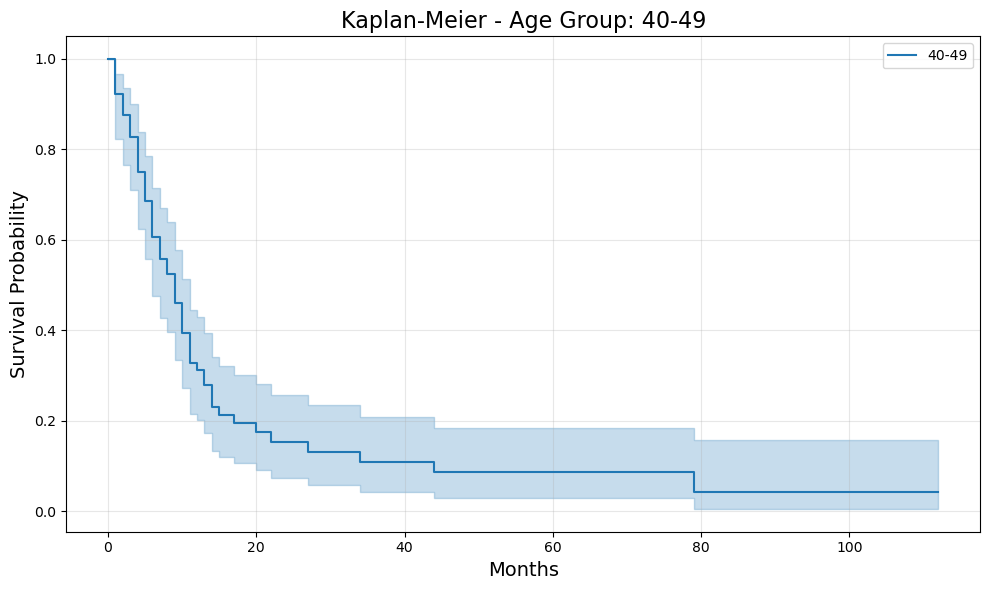

Group: 40-49
  Patients: 64
  Deaths: 56
  Median survival: 9.0 months
  95% CI:        40-49_lower_0.95  40-49_upper_0.95
0.0            1.000000          1.000000
1.0            0.822438          0.966716
2.0            0.765560          0.935434
3.0            0.711174          0.900910
4.0            0.624766          0.838664
5.0            0.556832          0.784840
6.0            0.475324          0.714296
7.0            0.428029          0.670432
8.0            0.395985          0.639893
9.0            0.333608          0.577274
10.0           0.273511          0.512590
11.0           0.215808          0.445733
12.0           0.201785          0.428654
13.0           0.174265          0.394023
14.0           0.134434          0.340774
15.0           0.120314          0.321660
17.0           0.106531          0.302264
18.0           0.106531          0.302264
20.0           0.091348          0.281296
21.0           0.091348          0.281296
22.0           0.074328          0.25

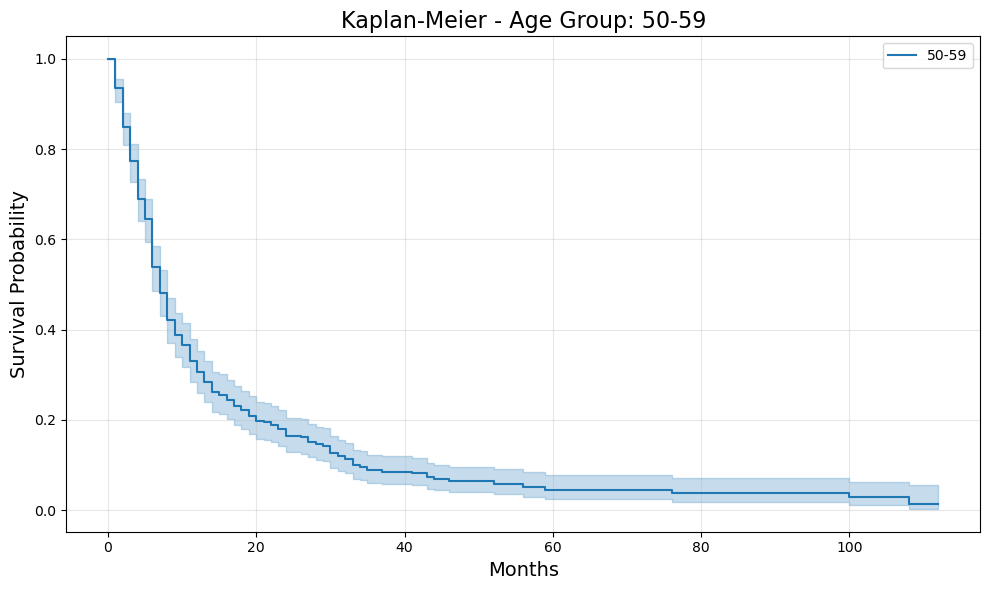

Group: 50-59
  Patients: 384
  Deaths: 346
  Median survival: 7.0 months
  95% CI:        50-59_lower_0.95  50-59_upper_0.95
0.0            1.000000          1.000000
1.0            0.905167          0.955533
2.0            0.808774          0.880936
3.0            0.727403          0.811550
4.0            0.639903          0.732712
5.0            0.593784          0.689788
6.0            0.486111          0.586247
7.0            0.430544          0.530955
8.0            0.370064          0.469363
9.0            0.338614          0.436728
10.0           0.317455          0.414566
11.0           0.283320          0.378317
12.0           0.259878          0.353041
13.0           0.238764          0.330073
14.0           0.217799          0.306964
15.0           0.212389          0.300995
16.0           0.201606          0.289024
17.0           0.188017          0.273839
18.0           0.179904          0.264690
19.0           0.169136          0.252447
20.0           0.158427          0.

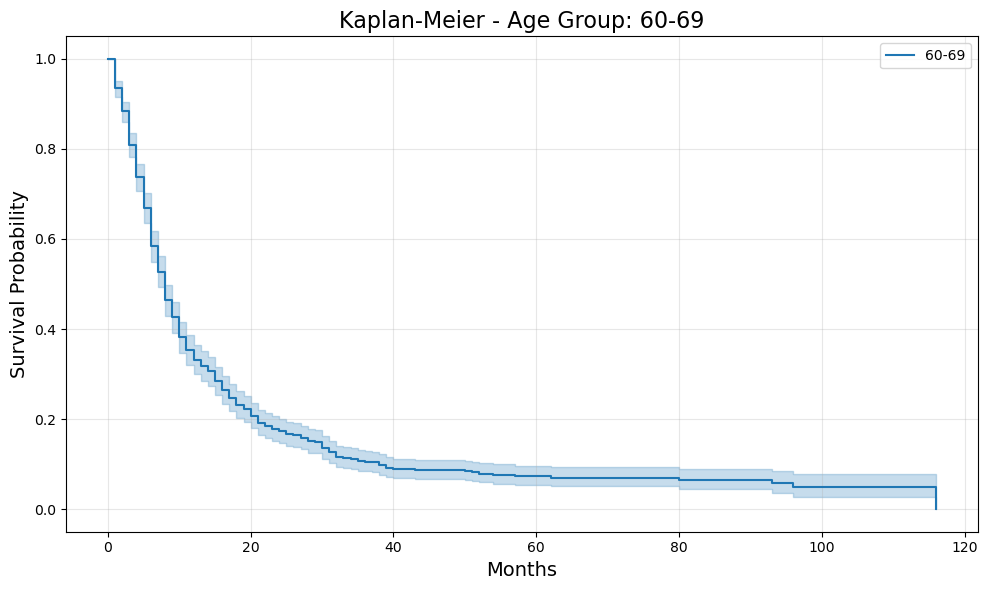

Group: 60-69
  Patients: 813
  Deaths: 712
  Median survival: 8.0 months
  95% CI:        60-69_lower_0.95  60-69_upper_0.95
0.0            1.000000          1.000000
1.0            0.915537          0.949805
2.0            0.860110          0.904339
3.0            0.780999          0.835174
4.0            0.705595          0.766365
...                 ...               ...
98.0           0.027719          0.079129
105.0          0.027719          0.079129
106.0          0.027719          0.079129
107.0          0.027719          0.079129
116.0          0.000000          0.000000

[75 rows x 2 columns]


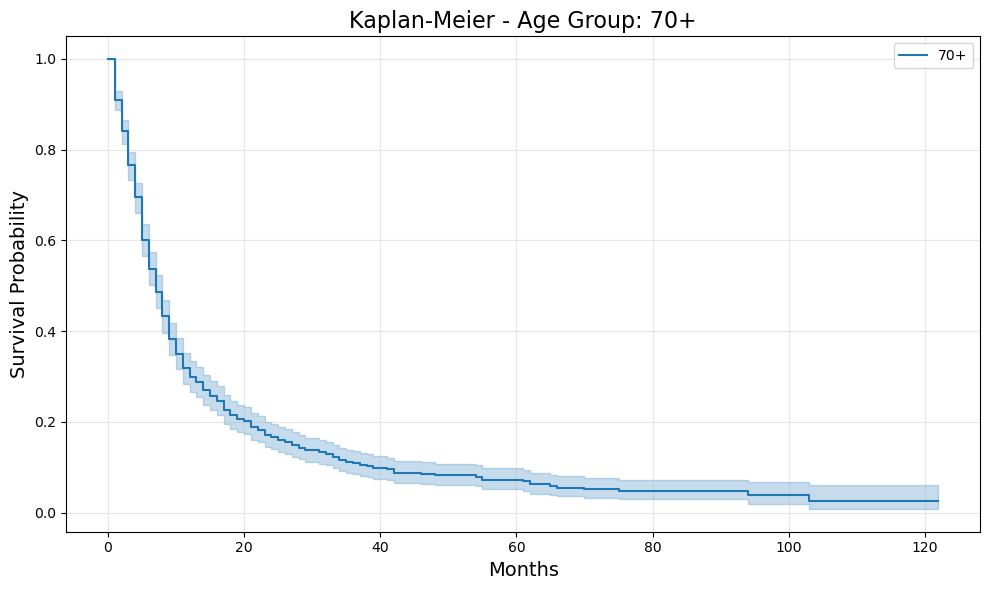

Group: 70+
  Patients: 731
  Deaths: 641
  Median survival: 7.0 months
  95% CI:        70+_lower_0.95  70+_upper_0.95
0.0          1.000000        1.000000
1.0          0.886516        0.928360
2.0          0.812635        0.865792
3.0          0.733005        0.794585
4.0          0.660289        0.727190
...               ...             ...
94.0         0.019121        0.067664
98.0         0.019121        0.067664
103.0        0.007891        0.061941
117.0        0.007891        0.061941
122.0        0.007891        0.061941

[71 rows x 2 columns]


In [8]:
age_groups = cancer_data["Age_Group"].cat.categories

for group in age_groups:
    mask = cancer_data["Age_Group"] == group
    if mask.sum() > 0:
        kmf = KaplanMeierFitter()
        kmf.fit(cancer_data[mask]["Survival_Months"], 
                event_observed=cancer_data[mask]["Survived"], 
                label=group)        
        
        plt.figure(figsize=(10, 6))
        kmf.plot_survival_function()
        plt.title(f"Kaplan-Meier - Age Group: {group}", fontsize=16)
        plt.xlabel("Months", fontsize=14)
        plt.ylabel("Survival Probability", fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
               
        print(f"Group: {group}")
        print(f"  Patients: {mask.sum():_}")
        print(f"  Deaths: {cancer_data[mask]['Survived'].sum():_}")
        print(f"  Median survival: {kmf.median_survival_time_:_.1f} months")
        print(f"  95% CI: {kmf.confidence_interval_}")
       

## 3. Stratified Survival Analysis: Risk Domain Visualizations
To understand how clinical indicators shift the survival probability, we stratify the cohort based on specific feature variables. Below, we plot the separate Kaplan-Meier curves for each subgroup to analyze differences in their median survival timelines.

## <center><span style="color:red;">**By Cancer Stage**</span></center>

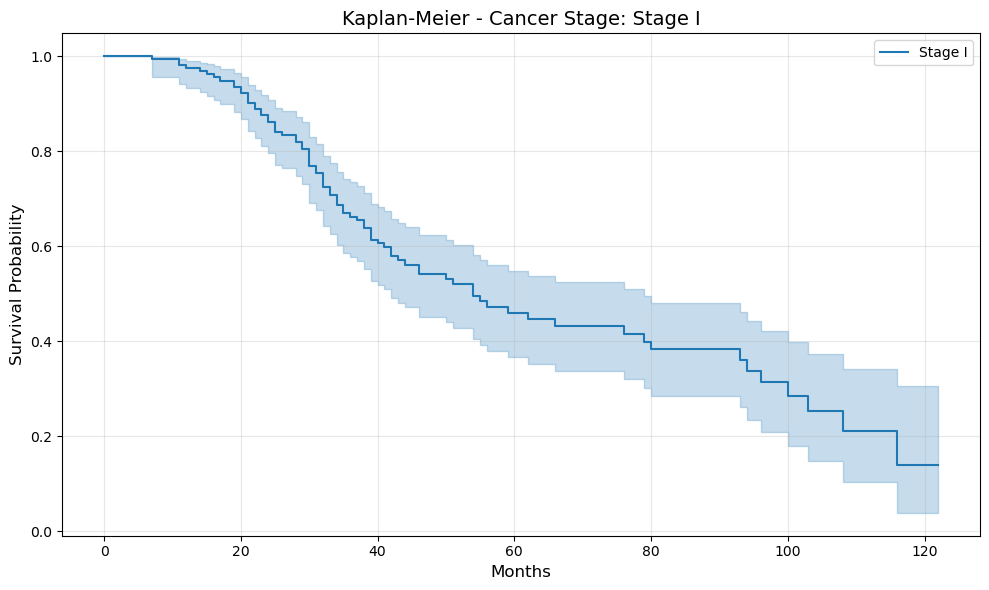

Group: Stage I
  Patients: 161
  Deaths: 81
  Median survival: 54.0 months
  95% CI:        Stage I_lower_0.95  Stage I_upper_0.95
0.0              1.000000            1.000000
6.0              1.000000            1.000000
7.0              0.955652            0.999100
11.0             0.941933            0.993797
12.0             0.933546            0.990361
...                   ...                 ...
108.0            0.104710            0.342173
112.0            0.104710            0.342173
116.0            0.038980            0.305655
117.0            0.038980            0.305655
122.0            0.038980            0.305655

[78 rows x 2 columns]


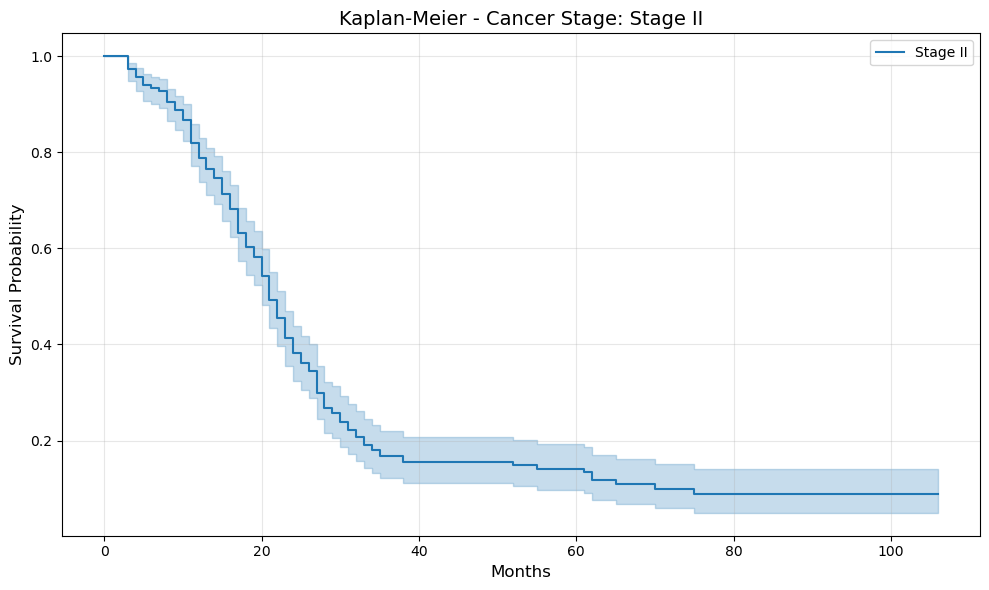

Group: Stage II
  Patients: 304
  Deaths: 231
  Median survival: 21.0 months
  95% CI:        Stage II_lower_0.95  Stage II_upper_0.95
0.0               1.000000             1.000000
3.0               0.948070             0.986752
4.0               0.927399             0.974910
5.0               0.907402             0.962170
6.0               0.899524             0.956893
7.0               0.891720             0.951540
8.0               0.864642             0.932205
9.0               0.845671             0.918024
10.0              0.823122             0.900635
11.0              0.770624             0.858444
12.0              0.737363             0.830594
13.0              0.711651             0.808571
14.0              0.693331             0.792643
15.0              0.656816             0.760347
16.0              0.624288             0.730960
17.0              0.573678             0.684271
18.0              0.544876             0.657173
19.0              0.523270             0.636610
2

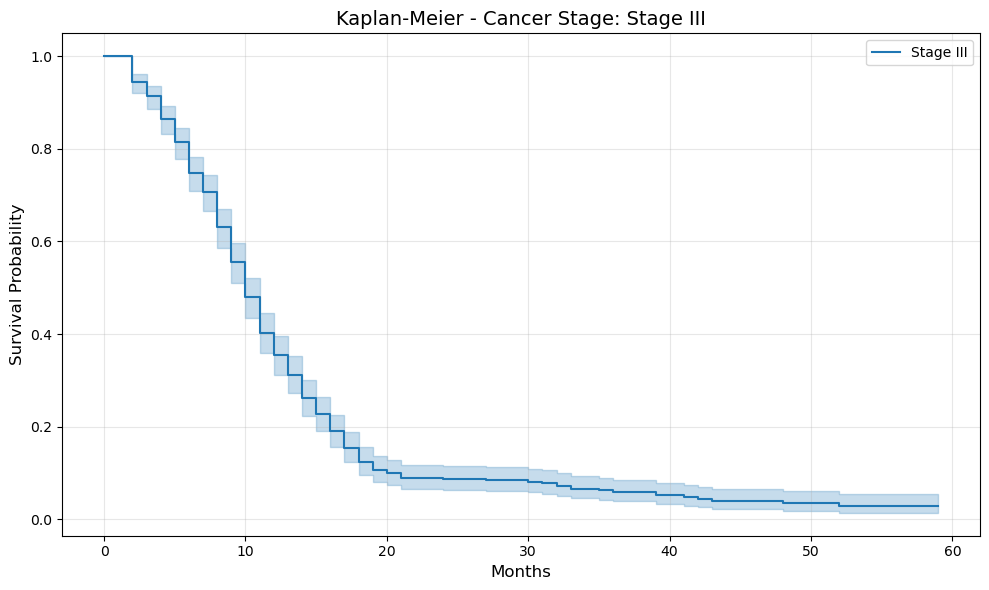

Group: Stage III
  Patients: 521
  Deaths: 468
  Median survival: 10.0 months
  95% CI:       Stage III_lower_0.95  Stage III_upper_0.95
0.0               1.000000              1.000000
2.0               0.920887              0.960984
3.0               0.885706              0.934594
4.0               0.832472              0.891623
5.0               0.778057              0.845297
6.0               0.708126              0.783187
7.0               0.665422              0.744127
8.0               0.586659              0.670209
9.0               0.511038              0.597086
10.0              0.435277              0.521979
11.0              0.359555              0.444956
12.0              0.312064              0.395511
13.0              0.272379              0.353494
14.0              0.222990              0.300107
15.0              0.190650              0.264544
16.0              0.156014              0.225682
17.0              0.123943              0.188610
18.0              0.095970    

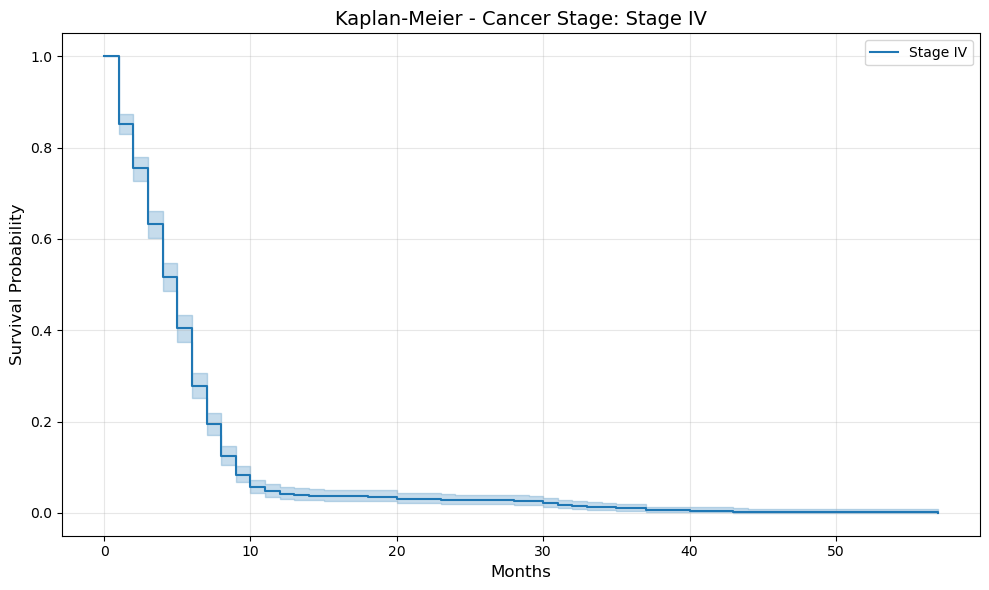

Group: Stage IV
  Patients: 1_014
  Deaths: 982
  Median survival: 5.0 months
  95% CI:       Stage IV_lower_0.95  Stage IV_upper_0.95
0.0              1.000000             1.000000
1.0              0.828698             0.872504
2.0              0.727144             0.780202
3.0              0.601789             0.661299
4.0              0.484760             0.546532
5.0              0.373492             0.434286
6.0              0.250947             0.306702
7.0              0.170169             0.219545
8.0              0.104832             0.146255
9.0              0.067429             0.102332
10.0             0.042857             0.072042
11.0             0.035479             0.062548
12.0             0.030928             0.056558
13.0             0.029069             0.054096
14.0             0.027162             0.051567
15.0             0.026214             0.050299
18.0             0.025268             0.049027
20.0             0.021523             0.043906
21.0             0.

In [9]:
stage_groups = cancer_data["Cancer_Stage"].unique()

for group in sorted(stage_groups):
    mask = cancer_data["Cancer_Stage"] == group
    kmf = KaplanMeierFitter()
    kmf.fit(cancer_data[mask]["Survival_Months"], 
            event_observed=cancer_data[mask]["Survived"], 
            label=group)    
   
    plt.figure(figsize=(10, 6))
    kmf.plot_survival_function()
    plt.title(f"Kaplan-Meier - Cancer Stage: {group}", fontsize=14)
    plt.xlabel("Months", fontsize=12)
    plt.ylabel("Survival Probability", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()    
   
    print(f"Group: {group}")
    print(f"  Patients: {mask.sum():_}")
    print(f"  Deaths: {cancer_data[mask]['Survived'].sum():_}")
    print(f"  Median survival: {kmf.median_survival_time_:_.1f} months")
    print(f"  95% CI: {kmf.confidence_interval_}")  
    

## 4. Analytical Conclusions & Saving the Engineered Clinical Dataset

Through this comprehensive non-parametric analysis utilizing the Kaplan-Meier product-limit framework, we have successfully mapped out the operational timeline and baseline survival indices of the pancreatic cancer patient cohort:

1. **Global Metrics Logged:** The collective median survival baseline and its respective confidence boundaries have been mathematically verified.
2. **Visual Impact of Disease Progression:** Based on the empirical survival curves, **the clinical stage of the cancer (`Cancer_Stage`) demonstrates the most prominent visual divergence in survival probabilities.** Patients at Stage IV experience a drastically steeper decline in survival over time compared to early-stage patients, resulting in heavily truncated median survival timelines. Visually, this feature appears to exert a dominant influence on patient outcomes compared to demographic categories like `Age_Group`.

### 4.1. Dataset Synchronization for Next Modeling Phases
While the Kaplan-Meier curves strongly suggest that `Cancer_Stage` is a primary driver of prognosis, non-parametric methods cannot mathematically isolate or rank the exact statistical weight (Hazard Ratios) of multiple confounding factors acting simultaneously. 

To systematically prove our hypothesis that tumor staging has the highest predictive risk weight compared to lifestyle factors (such as smoking or diabetes), we must transition into **Part 2: Multivariate Proportional Hazards Modeling (Cox Regression Analysis)**. 

To preserve the custom columns and metadata groups developed during this phase, we execute a permanent overwrite on our cleaned data source to ensure full data consistency for the upcoming parametric regressions.

In [10]:
cleaned_dataset_path = r"C:\Users\Dell\Desktop\PancreaticCancer\pancreatic_cancer_dataset_cleaned.csv"
cancer_data.to_csv(cleaned_dataset_path, index=False)